# SDC3b Posterior Comparison

This notebook compares the posterior probability distributions submitted by **26 teams** for the [SKA Data Challenge 3b (SDC3b)](https://sdc3.skao.int/).

Each team produced 3-D posterior grids over the neutral hydrogen fraction $x_\mathrm{HI}$ at three redshift bins, inferred from simulated 21-cm power spectra. The notebook:

1. Defines the ground-truth $x_\mathrm{HI}$ values from the SDC3b simulation.
2. Provides `GridCornerPlotter` — a utility for overlaying posterior corner plots from multiple teams.
3. Provides `ComparisonPlotter` — a subclass that computes statistical metrics to rank team performance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from glob import glob
from astropy.io import fits
import tools21cm as t2c

import corner
from getdist import plots, MCSamples
from scipy.linalg import inv
import pandas as pd

/Users/sgiri/miniforge3/envs/skao/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## True Model Data

The SDC3b simulation covers three frequency (redshift) bands:

| Band | Frequency range (MHz) | Redshift range |
|------|-----------------------|----------------|
| z1   | 151.0 – 165.9         | 8.46 – 7.57    |
| z2   | 166.0 – 180.9         | 7.57 – 6.92    |
| z3   | 181.0 – 195.9         | 6.92 – 6.31    |

For each band, three 21-cm power spectrum bins (`PS1`, `PS2`, `PS3`) were measured.  
The cells below define:
- `xhi_true_min_max` — the range of $x_\mathrm{HI}$ across each band.
- `xhi_true` — the volume-averaged $x_\mathrm{HI}$ used as the single-point ground truth for metric calculations.


In [2]:
freq_true = {
    'z1': [151.000, 165.900],
    'z2': [166.000, 180.900],
    'z3': [181.000, 195.900],
}

reds_true = {
    'z1': [8.461, 7.569],
    'z2': [7.569, 6.917],
    'z3': [6.917, 6.314],
}

In [3]:
xhi_true_min_max = {
    'z1': {
        'PS1':[0.8275, 0.5717],
        'PS2':[0.9493, 0.8730],
        'PS3':[0.8751, 0.6662],
    },
    'z2': {
        'PS1':[0.5717, 0.2308],
        'PS2':[0.8730, 0.7493],
        'PS3':[0.6662, 0.3824],
    },
    'z3': {
        'PS1':[0.2308, 0.0197],
        'PS2':[0.7493, 0.5460],
        'PS3':[0.3824, 0.1059],
    },
}

xhi_true = {
    'z1': {
        'PS1': 0.69960,
        'PS2': 0.91117,
        'PS3': 0.77064,
    },
    'z2': {
        'PS1': 0.40125,
        'PS2': 0.81115,
        'PS3': 0.52431,
    },
    'z3': {
        'PS1': 0.12525,
        'PS2': 0.64765,
        'PS3': 0.24418,
    },
}

## Visualisation Utilities

### `GridCornerPlotter`

A class for overlaying posterior corner plots from multiple submissions on a shared parameter space.

**Parameters**

| Parameter | Default | Description |
|-----------|---------|-------------|
| `engine` | `'corner'` | Backend: `'corner'` or `'getdist'` |
| `true_values` | `None` | Ground-truth list `[x1, x2, x3]`; plotted as dashed lines |
| `labels` | `[x_{HI,1}, ...]` | LaTeX parameter labels (no `$`) |

**Usage**
```python
plotter = GridCornerPlotter(engine='getdist', true_values=[0.70, 0.40, 0.13])
plotter.add_posterior(grid_3d, label='Team A', color='C0')
plotter.plot_corner()
```


In [4]:
class GridCornerPlotter:
    def __init__(self, engine='corner', true_values=None, labels=None):
        """
        Initialize the plotter.
        
        Parameters:
        - engine: 'corner' or 'getdist'
        - true_values: List of values [x1, x2, x3]
        - labels: List of LaTeX strings (no $ signs)
        """
        self.engine = engine.lower()
        self.true_values = true_values
        self.labels = labels or [r"x_{\mathrm{HI},1}", r"x_{\mathrm{HI},2}", r"x_{\mathrm{HI},3}"]
        self.posteriors = [] 
        self.coords_1d = np.linspace(0, 1, 100)
        
        # 30 visually distinct colours: tab20 (20) + first 10 of tab20b
        _cm1 = plt.get_cmap('tab20')
        _cm2 = plt.get_cmap('tab20b')
        self.fallback_cycle = [_cm1(i) for i in range(20)] + [_cm2(i) for i in range(10)]
        self.marker_cycle = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'P', 'X', '<', '>', 'd', '8']
        
    def add_posterior(self, grid, label, color=None, marker=None):
        """Add a 3D probability grid with an optional color and marker."""
        self.posteriors.append({
            'grid': grid,
            'label': label,
            'color': color,
            'marker': marker
        })
        
    def _prepare_weighted_samples(self, grid):
        """Flatten 3D grid into weighted points."""
        X1, X2, X3 = np.meshgrid(self.coords_1d, self.coords_1d, self.coords_1d, indexing='ij')
        points = np.vstack([X1.flatten(), X2.flatten(), X3.flatten()]).T
        weights = grid.flatten()
        return points, weights

    def plot_corner(self, **kwargs):
        if not self.posteriors:
            raise ValueError("No posteriors added. Call .add_posterior() first.")
        if self.engine == 'corner':
            return self._plot_corner_engine(**kwargs)
        elif self.engine == 'getdist':
            return self._plot_getdist_engine(**kwargs)

    def _plot_corner_engine(self, **kwargs):
        formatted_labels = [f"${l}$" for l in self.labels]
        fig = None
        legend_handles = []
        
        for i, post in enumerate(self.posteriors):
            points, weights = self._prepare_weighted_samples(post['grid'])
            
            # Determine color from user input or the C0-C9 cycle
            current_color = post['color'] if post['color'] else self.fallback_cycle[i % len(self.fallback_cycle)]
            
            opts = {
                'labels': formatted_labels,
                'bins': 40,
                'plot_datapoints': False,
                'fill_contours': True,
                'levels': (0.68, 0.95),
                'range': [(0, 1), (0, 1), (0, 1)],
                'color': current_color,
                'smooth': 1.0,    # Added smoothing as requested
                'smooth1d': 1.0,  # Added 1D smoothing as requested
            }
            
            if fig is not None:
                opts['fig'] = fig
            
            opts.update(kwargs)
            fig = corner.corner(points, weights=weights, **opts)
            
            # Create legend handle for the team
            legend_handles.append(mlines.Line2D([], [], color=current_color, label=post['label'], lw=2))
            
        if self.true_values is not None:
            # Mark true values in gray (lines and points) without adding to legend
            corner.overplot_lines(fig, self.true_values, color="gray", linestyle="--", alpha=0.6)
            corner.overplot_points(fig, np.expand_dims(self.true_values, 0), 
                                   color="gray", marker="s", markersize=5)

        # Place legend in the top-right empty space of the corner plot
        fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=12)
            
        return fig

    def _plot_getdist_engine(self, **kwargs):
        samples_list = []
        names = ["x1", "x2", "x3"]
        for i, post in enumerate(self.posteriors):
            points, weights = self._prepare_weighted_samples(post['grid'])
            s = MCSamples(samples=points, weights=weights, names=names, 
                          labels=self.labels, label=post['label'], ranges={n: (0, 1) for n in names})
            samples_list.append(s)
            
        g = plots.get_subplot_plotter()
        
        # Sync colors with the same C0-C9 cycle for GetDist
        user_colors = [p['color'] for p in self.posteriors]
        final_colors = [user_colors[i] if user_colors[i] else self.fallback_cycle[i % len(self.fallback_cycle)] 
                        for i in range(len(user_colors))]

        g.triangle_plot(samples_list, filled=True, contour_colors=final_colors,
                        markers=self.true_values, marker_args={'color': 'gray', 'ls': '--', 'alpha': 0.6},
                        **kwargs)
        return g

In [5]:
def read_fits_data(filename):
    hdul = fits.open(filename)
    data = hdul[0].data
    header = hdul[0].header
    hdul.close()
    return data, header

def get_posterior_data(team_name, ps_name):
    if isinstance(ps_name, int):
        ps_name = f'PS{ps_name}'
    if isinstance(team_name, int):
        team_name = f'Team_{team_name}'
    filename = f'mocks/{team_name}/{team_name}_{ps_name}.fits'
    data, header = read_fits_data(filename)
    return data, header

posterior_reader = lambda team, ps: get_posterior_data(team, ps)[0]

### Example: Corner Plot for a Single Power Spectrum Bin

Load posteriors for all teams and overlay them for a chosen power spectrum bin (`PS1`, `PS2`, or `PS3`)  
and a chosen redshift band (`z1`, `z2`, `z3`).


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


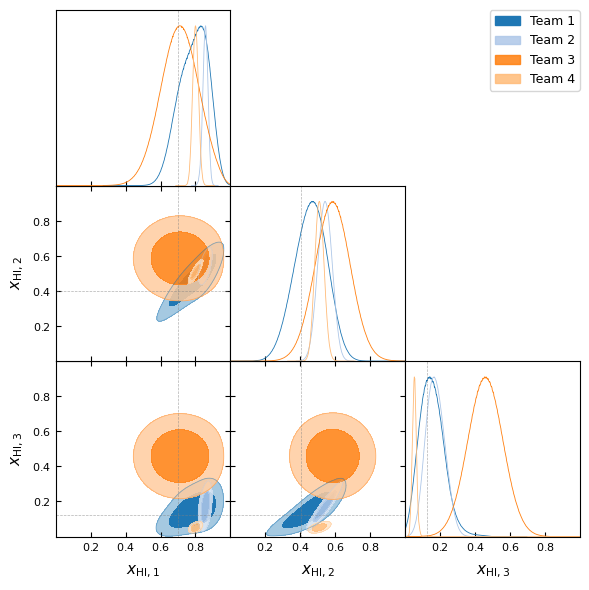

In [6]:
# Define the true values for the specific case (e.g., z1, PS1)
psname = 'PS1'
truths = [xhi_true[zname][psname] for zname in ['z1', 'z2', 'z3']]

# Initialize the plotter
plotter = GridCornerPlotter(engine='getdist', true_values=truths)

# Add data for different teams or settings
for team in np.arange(4)+1:
    teamname = f'Team_{team}'
    plotter.add_posterior(posterior_reader(teamname, psname), label=f'Team {team}')

# 4. Show the plot
fig = plotter.plot_corner()
plt.show()

## Quantitative Comparison: `ComparisonPlotter`

`ComparisonPlotter` extends `GridCornerPlotter` by computing statistical metrics for each team
immediately when a posterior is added.  All quantities are derived from the **marginal** posterior grid.

> **Notation:** We use $\theta_p$ (or index $p = 1,2,3$) for the inferred parameters
> $(x_{\mathrm{HI},1},\, x_{\mathrm{HI},2},\, x_{\mathrm{HI},3})$, reserving $k$ for
> Fourier wavenumber.

---

### Weighted Posterior Statistics

Given a 3-D posterior grid $P(\boldsymbol{\theta})$ with weights $w_i = P_i / \sum_j P_j$:

$$\boldsymbol{\mu} = \sum_i w_i\, \boldsymbol{\theta}_i, \qquad
\mathbf{C} = \sum_i w_i\,(\boldsymbol{\theta}_i - \boldsymbol{\mu})(\boldsymbol{\theta}_i - \boldsymbol{\mu})^T$$

The marginal uncertainty is $\sigma_p = \sqrt{C_{pp}}$.

---

### Metric 1 -- Credible Intervals (`plot_forest`)

**1$\sigma$ (68%)** and **2$\sigma$ (95%)** equal-tailed marginal credible intervals, computed
directly from the posterior CDF -- no Gaussianity assumed.  Centre marker = marginal median.

---

### Metric 2 -- Bias and Precision (`plot_precision_accuracy`)

$$\text{Bias}_p = \tilde{\theta}_p - \theta_{\mathrm{truth},p}, \qquad
\Delta_{68,p} = \mathrm{hi}_{1\sigma,p} - \mathrm{lo}_{1\sigma,p}$$

where $\tilde{\theta}_p$ is the marginal median and $\Delta_{68,p}$ is the full 68% CI width.

---

### Metric 3 -- Z-score (`get_metrics_table`)

$$Z_p = \frac{|\mu_p - \theta_{\mathrm{truth},p}|}{\sigma_p}$$

$Z_p < 1$: good recovery; $Z_p > 2$: significant tension.

---

### Metric 4 -- Mahalanobis Distance (`get_metrics_table`)

$$D_M = \sqrt{(\boldsymbol{\mu} - \boldsymbol{\theta}_{\mathrm{truth}})^T\, \mathbf{C}^{-1}\, (\boldsymbol{\mu} - \boldsymbol{\theta}_{\mathrm{truth}})}$$

Multivariate Z-score accounting for parameter correlations. $D_M \lesssim 1$: truth within the joint 1$\sigma$ region.

---

### Additional Diagnostic Metrics (`plot_metric_combinations`)

These are computed internally and accessible via `plot_metric_combinations(metric1, metric2)`.

| Metric key | Full definition |
|------------|------------------|
| `'Z'` | $Z_p = \lvert\mu_p - \theta_{\mathrm{truth},p}\rvert / \sigma_p$ -- per-parameter sigma deviation |
| `'Bias'` | $\tilde{\theta}_p - \theta_{\mathrm{truth},p}$ -- signed offset of median from truth |
| `'CI68'` | $\Delta_{68,p} = \mathrm{hi}_{1\sigma,p} - \mathrm{lo}_{1\sigma,p}$ -- full 68% CI width |
| `'PIT'` | $F_p(\theta_{\mathrm{truth},p}) \in [0,1]$ -- Probability Integral Transform: the CDF evaluated at the truth. Value $\approx 0.5$ = well-calibrated; near 0 or 1 = truth in a tail. |
| `'Mahalanobis'` | $D_M$ -- scalar multivariate distance (see above) |
| `'Cover_68'` | Number of parameters (0--3) whose 68% CI contains the truth |
| `'Cover_95'` | Number of parameters (0--3) whose 95% CI contains the truth |

Example: `comp.plot_metric_combinations('Z', 'PIT')` shows Z-score vs. PIT for each parameter.


In [ ]:
class ComparisonPlotter(GridCornerPlotter):
    def __init__(self, engine='corner', true_values=None, labels=None):
        super().__init__(engine=engine, true_values=true_values, labels=labels)
        if self.true_values is None:
            print('Warning: true_values not provided. Metrics will not be calculated.')

    def add_posterior(self, grid, label, color=None, marker=None):
        """Overrides base to calculate metrics immediately when data is added."""
        super().add_posterior(grid, label, color, marker)
        self.posteriors[-1]['stats'] = self._calculate_metrics(grid)

    def _marginal_credible_intervals(self, grid):
        """
        Asymmetric credible intervals from 1-D marginal posteriors.

        Marginalises the 3-D grid along the two non-target axes and reads
        percentiles from the CDF - no Gaussianity assumed.

        Returns a list of dicts (one per parameter p) with keys:
            median, lo1, hi1  -- equal-tailed 68% CI (16th / 84th percentile)
            lo2, hi2          -- equal-tailed 95% CI (2.5th / 97.5th percentile)
            cdf_at            -- callable: CDF evaluated at an arbitrary value
        """
        x = self.coords_1d
        cis = []
        for axis in range(3):
            other_axes = tuple(i for i in range(3) if i != axis)
            marginal = np.sum(grid, axis=other_axes)
            marginal = marginal / np.sum(marginal)
            cdf = np.cumsum(marginal)

            def quantile(q, _cdf=cdf, _x=x):
                return float(np.interp(q, _cdf, _x))

            def cdf_at(val, _cdf=cdf, _x=x):
                return float(np.interp(val, _x, _cdf))

            cis.append({
                'median': quantile(0.500),
                'lo1':    quantile(0.160),
                'hi1':    quantile(0.840),
                'lo2':    quantile(0.025),
                'hi2':    quantile(0.975),
                'cdf_at': cdf_at,
            })
        return cis

    def _calculate_metrics(self, grid):
        """Calculate weighted stats, credible intervals, Z-scores, Mahalanobis, PIT, and coverage."""
        X1, X2, X3 = np.meshgrid(self.coords_1d, self.coords_1d, self.coords_1d, indexing='ij')
        points  = np.vstack([X1.flatten(), X2.flatten(), X3.flatten()]).T
        weights = grid.flatten() / np.sum(grid)

        means  = np.average(points, axis=0, weights=weights)
        cov    = np.cov(points.T, aweights=weights)
        sigmas = np.sqrt(np.diag(cov))
        cis    = self._marginal_credible_intervals(grid)

        metrics = {'means': means, 'sigmas': sigmas, 'cov': cov, 'cis': cis}

        if self.true_values is not None:
            tv = np.asarray(self.true_values)
            metrics['z_scores']  = np.abs(means - tv) / sigmas

            delta = means - tv
            try:
                metrics['mahalanobis'] = float(np.sqrt(delta @ inv(cov) @ delta))
            except np.linalg.LinAlgError:
                metrics['mahalanobis'] = np.nan

            # PIT: CDF at truth; ~0.5 for a well-calibrated posterior
            metrics['pit'] = np.array([cis[p]['cdf_at'](tv[p]) for p in range(len(tv))])

            metrics['cover_68'] = np.array([cis[p]['lo1'] <= tv[p] <= cis[p]['hi1'] for p in range(len(tv))])
            metrics['cover_95'] = np.array([cis[p]['lo2'] <= tv[p] <= cis[p]['hi2'] for p in range(len(tv))])

        return metrics

    def plot_forest(self):
        """
        Horizontal whisker plot of 68% and 95% credible intervals for each team.
        Centre marker = marginal median.  Use plot_colour_legend() to identify teams.
        """
        num_teams  = len(self.posteriors)
        num_params = len(self.labels)
        fig, axes  = plt.subplots(1, num_params, figsize=(14, num_teams * 0.4 + 2), sharey=True)
        if num_params == 1:
            axes = [axes]

        for p in range(num_params):
            ax = axes[p]
            for i, post in enumerate(self.posteriors):
                ci     = post['stats']['cis'][p]
                med    = ci['median']
                color  = post['color']  or self.fallback_cycle[i % len(self.fallback_cycle)]
                marker = post['marker'] or self.marker_cycle[i % len(self.marker_cycle)]
                ax.errorbar(med, i, xerr=[[med - ci['lo2']], [ci['hi2'] - med]],
                            fmt='none', color=color, lw=1, alpha=0.4)
                ax.errorbar(med, i, xerr=[[med - ci['lo1']], [ci['hi1'] - med]],
                            fmt=marker, color=color, lw=3, markersize=40)
            if self.true_values is not None:
                ax.axvline(self.true_values[p], color='gray', ls='--', alpha=0.7)
            ax.set_xlabel(f'${self.labels[p]}$')
            if p == 0:
                ax.set_yticks(range(num_teams))
                ax.set_yticklabels([post['label'] for post in self.posteriors])
            ax.invert_yaxis()
        fig.tight_layout()
        return fig

    def plot_precision_accuracy(self, markersize=80):
        """
        Scatter: Bias (median - truth) vs. 68% CI width for each parameter.
        Use plot_colour_legend() to identify teams.
        """
        num_params = len(self.labels)
        fig, axes  = plt.subplots(1, num_params, figsize=(15, 5))
        for p in range(num_params):
            ax = axes[p]
            for i, post in enumerate(self.posteriors):
                ci    = post['stats']['cis'][p]
                bias  = ci['median'] - self.true_values[p]
                width = ci['hi1'] - ci['lo1']
                color  = post['color']  or self.fallback_cycle[i % len(self.fallback_cycle)]
                marker = post['marker'] or self.marker_cycle[i % len(self.marker_cycle)]
                ax.scatter(bias, width, color=color, marker=marker, edgecolors='k', s=markersize, zorder=3)
            ax.axvline(0, color='gray', lw=1, ls='--')
            ax.set_xlabel(f'Bias  ($\\tilde{{\\theta}}_{p+1} - \\theta_{{\\mathrm{{truth}},{p+1}}}$)')
            ax.set_ylabel(r'68% CI width  $\Delta_{68}$')
            ax.set_title(f'${self.labels[p]}$')
        fig.tight_layout()
        return fig

    # ----------------------------------------------------------------
    # Metric labels for axes
    _METRIC_LABELS = {
        'Z':           r'$Z_p = |\mu_p - \theta_{\mathrm{truth},p}|\,/\,\sigma_p$',
        'PIT':         r'$F_p(\theta_{\mathrm{truth},p})$',
        'Bias':        r'$\tilde{\theta}_p - \theta_{\mathrm{truth},p}$',
        'CI68':        r'$\Delta_{68,p}$',
        'Mahalanobis': r'$D_M$',
        'Cover_68':    'Cover 68%',
        'Cover_95':    'Cover 95%',
    }
    _PER_PARAM = {'Z', 'PIT', 'Bias', 'CI68'}

    # Ideal reference values: where a perfectly calibrated posterior should sit
    # PIT=0.5: truth at the posterior median; Z=0/Bias=0: no offset; D_M=1: 1-sigma boundary
    _IDEAL_VALUES = {
        'Z':           0.0,   # no tension between mean and truth
        'PIT':         0.5,   # truth at the posterior median (well-calibrated)
        'Bias':        0.0,   # no systematic offset
        'Mahalanobis': 1.0,   # truth on the 1-sigma joint boundary
        'Cover_68':    3,     # all 3 parameters covered
        'Cover_95':    3,
    }

    def _get_metric_value(self, post, metric, p=None):
        s = post['stats']
        tv = np.asarray(self.true_values)
        if metric == 'Z':           return s['z_scores'][p]
        if metric == 'PIT':         return s['pit'][p]
        if metric == 'Bias':        return s['cis'][p]['median'] - tv[p]
        if metric == 'CI68':        return s['cis'][p]['hi1'] - s['cis'][p]['lo1']
        if metric == 'Mahalanobis': return s.get('mahalanobis', np.nan)
        if metric == 'Cover_68':    return int(np.sum(s['cover_68']))
        if metric == 'Cover_95':    return int(np.sum(s['cover_95']))
        raise ValueError(f'Unknown metric: {metric!r}. '
                         f'Choose from {sorted(self._METRIC_LABELS)}')

    def plot_metric_combinations(self, metric1, metric2, markersize=80):
        """
        Scatter plot comparing two metrics across all teams.

        Per-parameter metrics (three panels, one per parameter):
            'Z', 'PIT', 'Bias', 'CI68'
        Scalar metrics (single panel):
            'Mahalanobis', 'Cover_68', 'Cover_95'

        Use plot_colour_legend() to identify teams.

        Example:
            comp.plot_metric_combinations('Z', 'PIT')
            comp.plot_metric_combinations('Bias', 'CI68')
        """
        per_param = (metric1 in self._PER_PARAM) or (metric2 in self._PER_PARAM)
        n_panels  = len(self.labels) if per_param else 1

        fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
        if n_panels == 1:
            axes = [axes]

        ideal1 = self._IDEAL_VALUES.get(metric1)
        ideal2 = self._IDEAL_VALUES.get(metric2)

        for panel in range(n_panels):
            ax = axes[panel]
            p1 = panel if metric1 in self._PER_PARAM else None
            p2 = panel if metric2 in self._PER_PARAM else None

            for i, post in enumerate(self.posteriors):
                x = self._get_metric_value(post, metric1, p1)
                y = self._get_metric_value(post, metric2, p2)
                color  = post['color']  or self.fallback_cycle[i % len(self.fallback_cycle)]
                marker = post['marker'] or self.marker_cycle[i % len(self.marker_cycle)]
                ax.scatter(x, y, color=color, marker=marker, edgecolors='k', s=markersize, zorder=3)

            # Reference lines at ideal values
            if ideal1 is not None:
                ax.axvline(ideal1, color='gray', ls='--', lw=1, alpha=0.7, zorder=1)
            if ideal2 is not None:
                ax.axhline(ideal2, color='gray', ls='--', lw=1, alpha=0.7, zorder=1)
            # Star marking the ideal point when both axes have a reference
            if ideal1 is not None and ideal2 is not None:
                ax.scatter(ideal1, ideal2, marker='*', s=markersize * 2, color='gold',
                           edgecolors='k', lw=0.8, zorder=5, label='ideal')

            ax.set_xlabel(self._METRIC_LABELS.get(metric1, metric1))
            ax.set_ylabel(self._METRIC_LABELS.get(metric2, metric2))
            if per_param:
                ax.set_title(f'${self.labels[panel]}$')

        fig.tight_layout()
        return fig

    def plot_colour_legend(self, ncol=2):
        """Standalone colour legend panel for team identification."""
        handles = [
            mlines.Line2D([], [],
                          color=post['color']  or self.fallback_cycle[i % len(self.fallback_cycle)],
                          marker=post['marker'] or self.marker_cycle[i % len(self.marker_cycle)],
                          linestyle='none', markersize=8, label=post['label'])
            for i, post in enumerate(self.posteriors)
        ]
        n     = len(handles)
        nrows = int(np.ceil(n / ncol))
        fig, ax = plt.subplots(figsize=(ncol * 2.5, nrows * 0.4 + 0.5))
        ax.legend(handles=handles, ncol=ncol, loc='center', frameon=False, fontsize=9)
        ax.axis('off')
        fig.tight_layout()
        return fig

    def get_metrics_table(self, sort_metric='Mahalanobis'):
        """
        DataFrame of Z-scores and Mahalanobis distance for each team.
        sort_metric: any column name; default 'Mahalanobis' (lower = better).
        """
        rows = []
        for post in self.posteriors:
            s   = post['stats']
            row = {'Team': post['label']}
            for p, z in enumerate(s.get('z_scores', [])):
                row[f'Z_{p+1}'] = round(z, 3)
            row['Mahalanobis'] = round(s.get('mahalanobis', np.nan), 3)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_metric in df.columns:
            df = df.sort_values(sort_metric)
        return df


## Running the Full 26-Team Comparison

The cell below loads all 26 team posteriors for `PS1` (z1 band), computes all metrics,
prints the ranking table, and produces the forest and bias–precision plots.


       Team     Z_1     Z_2     Z_3  Mahalanobis
23  Team 24   0.197   0.279   0.395        0.522
10  Team 11   0.899   0.272   0.947        1.334
0    Team 1   1.106   0.639   0.408        1.412
9   Team 10   0.117   0.993   1.425        1.564
20  Team 21   0.071   0.619   0.563        1.905
18  Team 19   2.298   1.619   0.023        2.506
17  Team 18   3.145   2.554   1.151        3.341
25  Team 26   0.686   0.337   0.681        3.382
2    Team 3   0.083   1.833   3.329        3.802
15  Team 16   1.349   2.901   3.765        3.952
19  Team 20   0.451   3.498   3.260        4.803
21  Team 22   1.193   0.227   1.355        5.431
11  Team 12   1.734   1.471   3.408        6.272
7    Team 8   4.893   2.325   7.915        9.567
12  Team 13   1.409   4.011   3.899       10.432
13  Team 14   2.106   3.731   5.281       10.477
6    Team 7   9.920   3.816   0.642       10.997
1    Team 2  11.124   3.688   0.908       11.677
3    Team 4   7.081   4.705   6.248       12.186
5    Team 6   5.012 

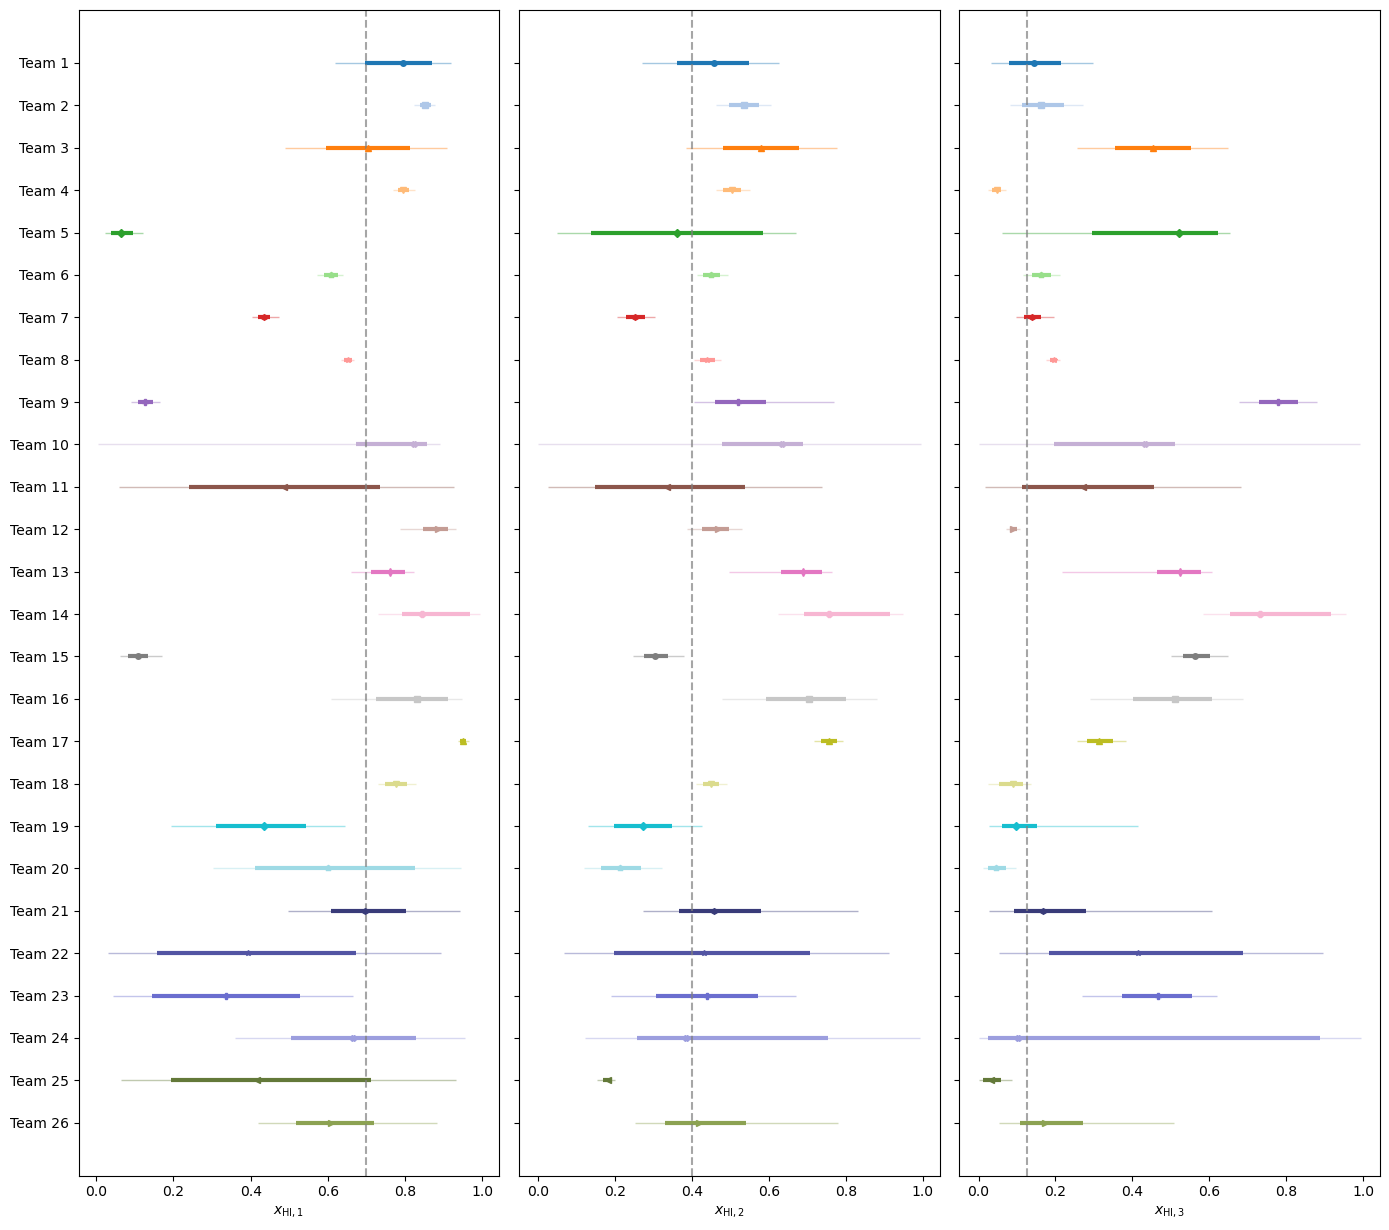

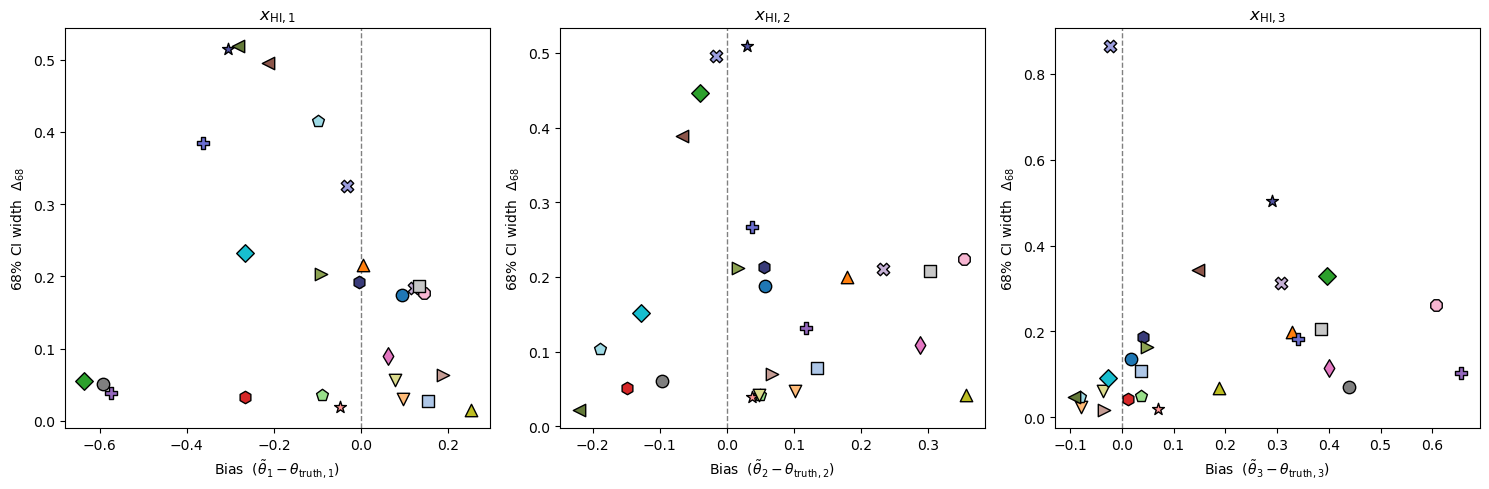

In [8]:
# Initialize child class
truths = [0.69960, 0.40125, 0.12525] 
comp = ComparisonPlotter(engine='getdist', true_values=truths)

# Loop through all your teams in the mocks folder
for team_id in range(1, 27):
   data = posterior_reader(team_id, 1)
   comp.add_posterior(data, label=f'Team {team_id}')

# See who is actually winning
df = comp.get_metrics_table()
print(df)

# View the forest plot to check for systematic offsets
comp.plot_forest();

# Check for overconfidence (Low sigma but high bias)
comp.plot_precision_accuracy();

### Team Colour Key

Run this cell first to identify teams across all plots below.


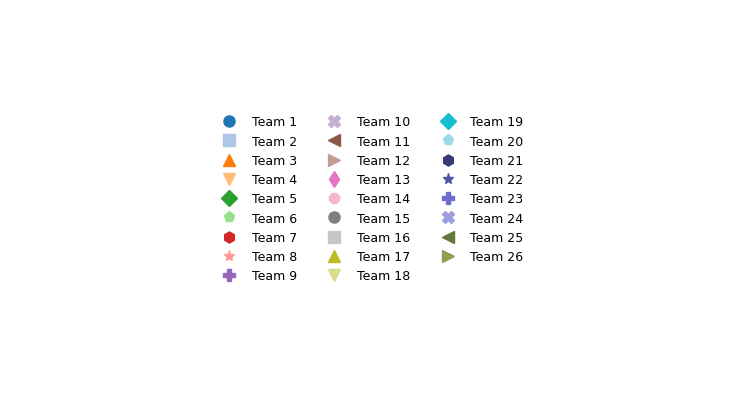

In [9]:
comp.plot_colour_legend(ncol=3);

### Metric Combination Plots

Each call to `plot_metric_combinations(metric1, metric2)` produces one scatter panel per parameter.

| Combination | What it reveals |
|-------------|-----------------|
| `'Z'` vs `'PIT'` | Both measure how far truth lies from the posterior, but via different assumptions. Z-score uses the Gaussian $\mu/\sigma$ approximation; PIT reads the actual CDF. Agreement between them indicates the marginal posteriors are approximately Gaussian; divergence reveals skewness or non-Gaussianity. |
| `'Bias'` vs `'CI68'` | Accuracy vs. precision per parameter. Ideal teams cluster near $(0, \text{small})$. Overconfident teams have small $\Delta_{68}$ but large bias. |
| `'Z'` vs `'CI68'` | Tension vs. posterior width. A high Z-score with a narrow CI indicates overconfidence: the posterior is tight but offset from truth. |
| `'PIT'` vs `'CI68'` | Calibration vs. width. Well-calibrated teams have PIT $\approx 0.5$ regardless of CI width. PIT near 0 or 1 flags posteriors that systematically under- or over-estimate $x_{\mathrm{HI}}$. |


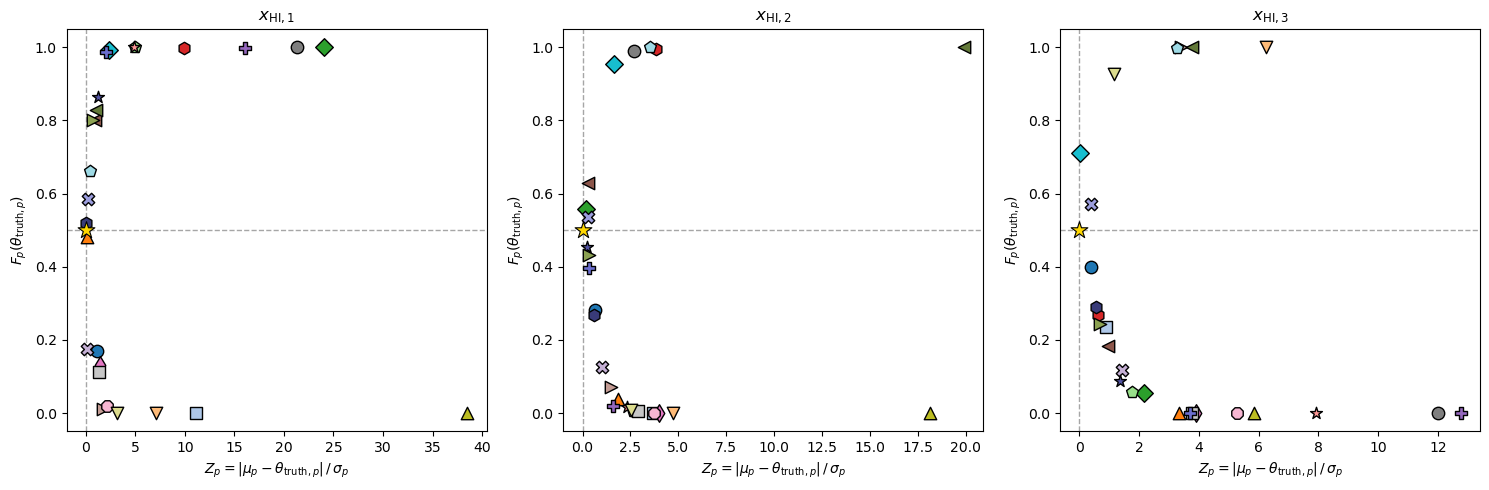

In [10]:
# Z-score vs PIT: Gaussian approximation vs actual CDF calibration
comp.plot_metric_combinations('Z', 'PIT');

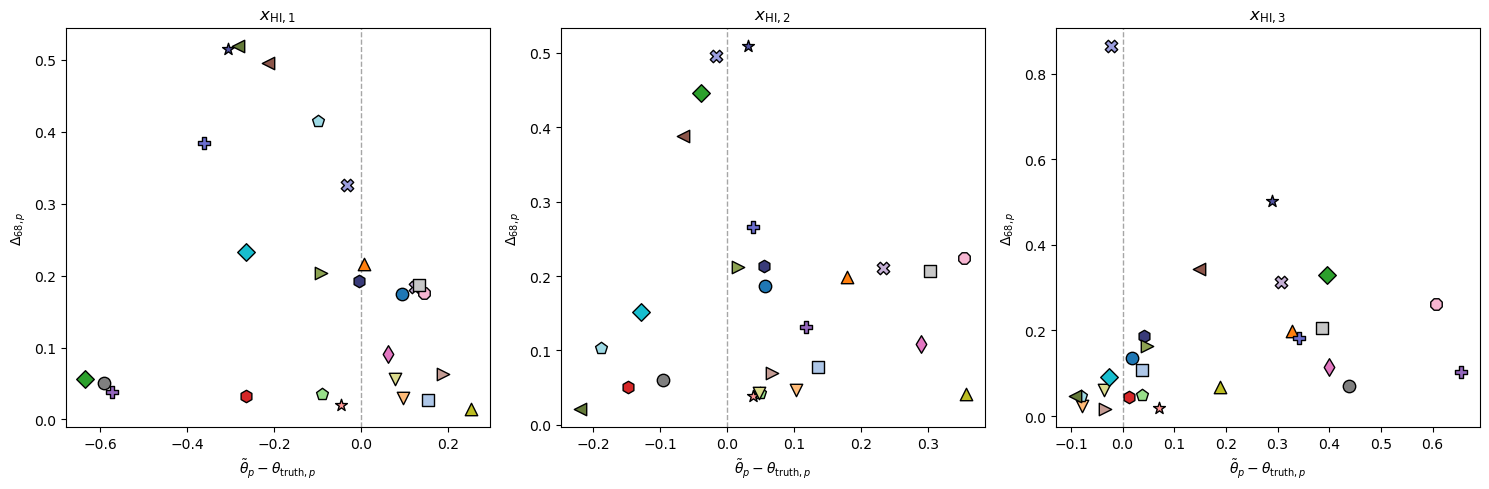

In [11]:
# Bias vs CI width: accuracy vs precision
comp.plot_metric_combinations('Bias', 'CI68');

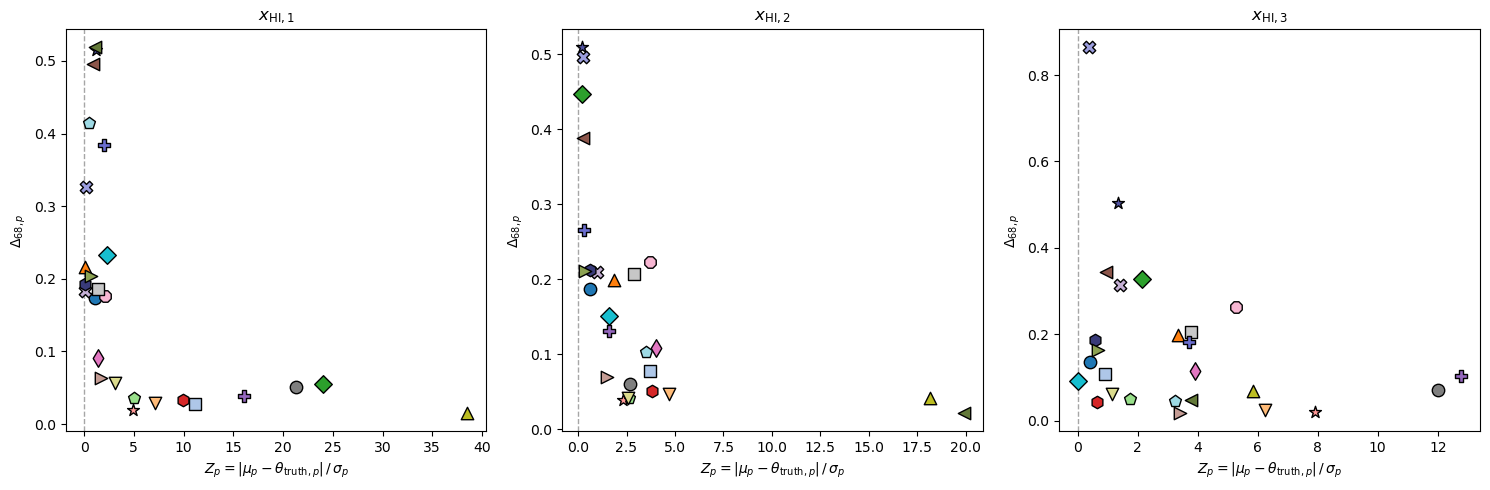

In [12]:
# Z-score vs CI width: overconfident teams sit top-left (high Z, narrow CI)
comp.plot_metric_combinations('Z', 'CI68');

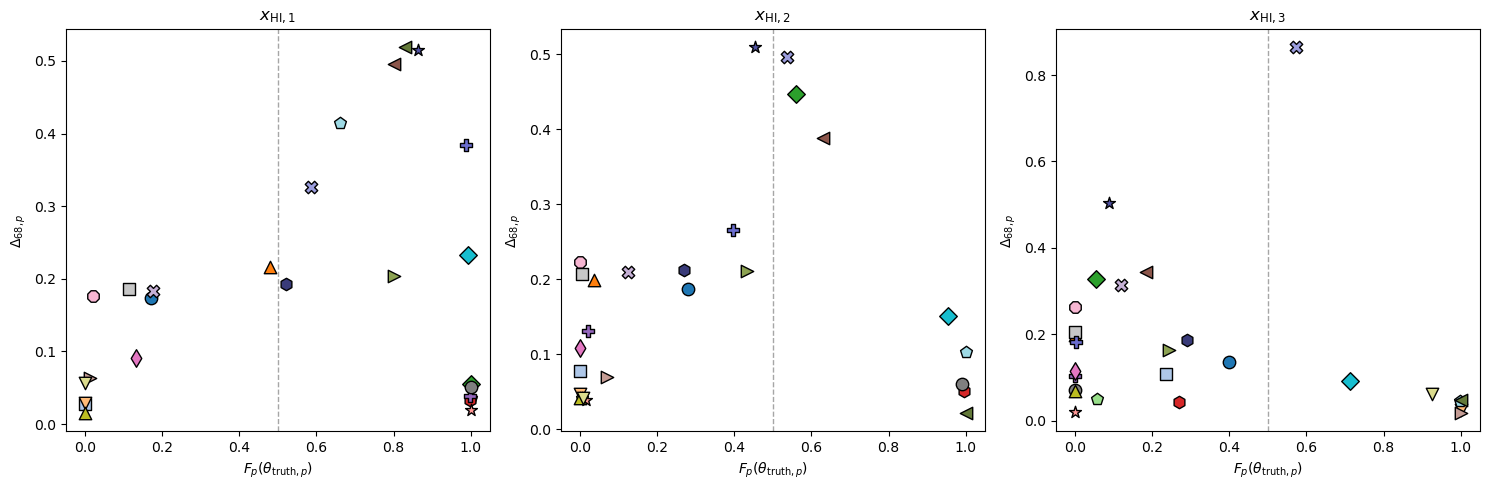

In [13]:
# PIT vs CI width: calibration independent of posterior width
comp.plot_metric_combinations('PIT', 'CI68');